# Solución para oscilaciones no lineales

Utilice las rutina rk4 para estudiar oscilaciones anarmónicas probando potencias en el rango $p = 2-12$ para el potencial.

$$V(x)=\frac{1}{p}kx^{p} $$

No incluya todavía ninguna fuerza explícita dependiente del tiempo. Tenga
en cuenta que para grandes valores de p, las fuerzas y aceleraciones se hacen grandes cerca de los puntos de inflexión, por lo que puede necesitar un tamaño de paso más pequeño h que el utilizado para el oscilador armónico.

1.   Comprueba que la solución sigue siendo periódica con amplitud y periodo constantes para todas las condiciones iniciales, independientemente de las fuerzas que implementan efectos no lineales. Además, compruebe que la velocidad máxima se produce en $x= 0$ y la velocidad cero en el máximo valor de las $x-es$, siendo este último una consecuencia de la conservación de la energía.
2.   Compruebe que los osciladores no armónicos son ***no isócronos***, es decir, que vibraciones con amplitudes diferentes tienen periodos diferentes.
3. Explique por qué las formas de las oscilaciones cambian para diferentes valores de $p$.
4. Diseña un algoritmo para determinar el periodo T de la oscilación registrando los momentos en los que la masa pasa por el origen. Ten en cuenta que, como el movimiento puede ser asimétrico, debes registrar al menos tres veces para deducir el periodo.
5. Construye una gráfica del periodo deducido en función de la amplitud inicial.
6. Verifique que el movimiento es oscilatorio, pero no armónico, a medida que $p$ sepra el valor de $6$.

## Marco Teórico

### Potencial anarmónico general

El potencial de la forma

$$V(x) = \frac{1}{p}\,k\,x^p, \qquad p = 2, 4, 6, \ldots$$

genera la fuerza restauradora (por la segunda ley de Newton):

$$F(x) = -\frac{dV}{dx} = -k\,x^{p-1}$$

La ecuación de movimiento es entonces:

$$m\ddot{x} = -k\,x^{p-1}$$

Para $p=2$ se recupera el **oscilador armónico simple** ($F = -kx$). Para $p > 2$ el sistema es **no lineal y anarmónico**.

### Sistema de EDOs de primer orden

Definiendo el vector de estado $\mathbf{y} = (x,\, v)^T$, el problema se convierte en:

$$\dot{x} = v$$
$$\dot{v} = -\frac{k}{m}\,x^{p-1}$$

que se integra numéricamente con el método **Runge-Kutta de cuarto orden (RK4)**.

### Conservación de la energía

La energía total se conserva:

$$E = \frac{1}{2}m\,v^2 + \frac{1}{p}k\,x^p = \text{cte}$$

En el punto de retorno ($x = x_{\max}$) toda la energía es potencial:

$$E = \frac{1}{p}k\,x_{\max}^p \implies v(x_{\max}) = 0$$

En el origen ($x = 0$) toda la energía es cinética:

$$E = \frac{1}{2}m\,v_{\max}^2 \implies v_{\max} = \sqrt{\frac{2E}{m}}$$

### Periodo analítico (referencia)

Para el potencial $V = \frac{k}{p}x^p$, integrando la condición de energía, se puede demostrar que el periodo exacto es:

$$T(A) = \frac{4}{A^{p/2-1}}\sqrt{\frac{m\,p}{2k}} \int_0^1 \frac{du}{\sqrt{1 - u^p}}$$

La integral es expresable en términos de la función Beta:

$$\int_0^1 \frac{du}{\sqrt{1-u^p}} = \frac{1}{p}B\!\left(\frac{1}{p},\,\frac{1}{2}\right) = \frac{\sqrt{\pi}}{p}\frac{\Gamma(1/p)}{\Gamma(1/p + 1/2)}$$

Nótese que para $p=2$ se obtiene $T = 2\pi\sqrt{m/k}$ (independiente de $A$), mientras que para $p > 2$ el periodo **depende de la amplitud** $A$ — el oscilador es **no isócrono**.

La dependencia con la amplitud sigue la ley de potencias:

$$T(A) \propto A^{1 - p/2}$$

- Para $p > 2$: el exponente $1-p/2 < 0$, por lo que a **mayor amplitud, menor periodo**.
- Para $p = 2$: el exponente es $0$, $T$ es constante (isócrono).

### Forma de las oscilaciones

La forma temporal $x(t)$ cambia con $p$ porque la fuerza restauradora cambia su perfil:

- **$p=2$ (armónico):** fuerza lineal $\Rightarrow$ oscilación sinusoidal perfecta.
- **$p$ grande (caja de potencial):** la fuerza es casi cero lejos del origen y enormemente grande cerca de $x_{\max}$, comportándose como una **partícula en caja**. La masa se mueve a velocidad aproximadamente constante entre las paredes, generando una forma de onda casi **cuadrada** (triangular en $x(t)$).
- **$p$ par intermedio ($p=4,6$):** formas de onda intermedias, más planas en los máximos que la senoidal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import gamma
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, fixed
from IPython.display import display

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:
# ─── RK4 integrator ───────────────────────────────────────────────────────────

def rk4_step(f, t, y, h):
    """Single RK4 step: returns y_{n+1}."""
    k1 = f(t,        y)
    k2 = f(t + h/2,  y + h/2 * k1)
    k3 = f(t + h/2,  y + h/2 * k2)
    k4 = f(t + h,    y + h   * k3)
    return y + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)


def rk4_integrate(f, t_span, y0, h):
    """Integrate from t_span[0] to t_span[1] with fixed step h."""
    t0, tf = t_span
    N = int(np.ceil((tf - t0) / h))
    t = np.empty(N + 1)
    y = np.empty((N + 1, len(y0)))
    t[0] = t0
    y[0] = y0
    for i in range(N):
        hi = min(h, tf - t[i])          # last step may be shorter
        y[i+1] = rk4_step(f, t[i], y[i], hi)
        t[i+1] = t[i] + hi
    return t, y


# ─── Equations of motion ──────────────────────────────────────────────────────

def make_ode(p, k=1.0, m=1.0):
    """Return the RHS function for dx/dt=v, dv/dt = -(k/m)*x^(p-1)."""
    def f(t, y):
        x, v = y
        return np.array([v, -(k / m) * x**(p - 1)])
    return f


# ─── Step-size selector (smaller h for large p near the turning point) ────────

def choose_h(p, A, k=1.0, m=1.0):
    """Adaptive h: for large p the acceleration near x=A is huge."""
    a_max = (k / m) * A**(p - 1)
    h_dyn = 0.01 / np.sqrt(a_max + 1.0)  # keep Δv/v_max < ~1 %
    return min(5e-4, h_dyn)


# ─── Period detection (zero-crossings of x) ───────────────────────────────────

def detect_period(t, y, min_crossings=6):
    """
    Find when x(t) crosses zero with positive velocity (upward-going).
    Period = mean interval between consecutive such crossings.
    We need at least min_crossings crossings to average.
    """
    x = y[:, 0]
    v = y[:, 1]
    # upward zero-crossings: x changes sign from - to +
    crossings = []
    for i in range(len(x) - 1):
        if x[i] <= 0 < x[i+1]:   # upward crossing
            # linear interpolation for sub-step accuracy
            frac = -x[i] / (x[i+1] - x[i])
            crossings.append(t[i] + frac * (t[i+1] - t[i]))
    if len(crossings) < 2:
        return np.nan
    intervals = np.diff(crossings)
    return np.mean(intervals)


# ─── Analytical period ────────────────────────────────────────────────────────

def T_analytic(p, A, k=1.0, m=1.0):
    """
    T(A) = 4*A^(1-p/2) * sqrt(m*p/(2k)) * B(1/p, 1/2) / p
    where B is the Beta function.
    """
    beta_val = gamma(1.0 / p) * gamma(0.5) / gamma(1.0 / p + 0.5)
    T = (4.0 / p) * beta_val * A**(1 - p/2) * np.sqrt(m * p / (2 * k))
    return T

print("Core functions defined: rk4_step, rk4_integrate, make_ode, choose_h, detect_period, T_analytic")

Core functions defined: rk4_step, rk4_integrate, make_ode, choose_h, detect_period, T_analytic


---
## Numeral 1 — Periodicidad, amplitud constante y conservación de energía

### Teoría

Para cualquier potencial par $V(x) = \frac{k}{p}x^p$ (con $p$ par), la energía total

$$E = \frac{1}{2}mv^2 + \frac{k}{p}x^p = \text{const}$$

implica que el movimiento está **confinado** al intervalo $[-A, A]$ donde $A = \left(\frac{pE}{k}\right)^{1/p}$.

- La **amplitud es constante** porque $E$ no cambia (no hay disipación).
- El **periodo es constante** para una amplitud dada (el hamiltoniano no depende explícitamente del tiempo).
- La **velocidad es máxima en $x=0$**: $v_{\max} = \sqrt{2E/m}$.
- La **velocidad es cero en $x = \pm A$**: toda la energía es potencial.

En el siguiente código se verifica numéricamente que la energía se conserva con error relativo $< 10^{-8}$ (precisión doble de RK4 con paso pequeño).

In [3]:
def run_simulation(p, A, n_periods=8, k=1.0, m=1.0):
    """Integrate for ~n_periods and return (t, x, v)."""
    T_est = T_analytic(p, A, k, m)
    tf    = n_periods * T_est
    h     = choose_h(p, A, k, m)
    f     = make_ode(p, k, m)
    y0    = np.array([A, 0.0])   # start at x=A, v=0
    t, y  = rk4_integrate(f, (0, tf), y0, h)
    return t, y[:, 0], y[:, 1]


def plot_numeral1(p):
    p = int(p)
    A = 1.0
    t, x, v = run_simulation(p, A, n_periods=10)
    E  = 0.5 * v**2 + (1.0/p) * x**p
    E0 = E[0]

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(t, x, color='steelblue', lw=1)
    axes[0].axhline(A,  ls='--', color='k', lw=0.8, label=f'$x_{{max}}={A}$')
    axes[0].axhline(-A, ls='--', color='k', lw=0.8)
    axes[0].set_ylabel('$x(t)$')
    axes[0].set_title(f'Oscilador anarmónico  $p={p}$,  $A={A}$')
    axes[0].legend()

    axes[1].plot(t, v, color='coral', lw=1)
    axes[1].axhline(np.sqrt(2 * E0), ls='--', color='k', lw=0.8,
                    label=f'$v_{{max}}={np.sqrt(2*E0):.4f}$')
    axes[1].set_ylabel('$v(t)$')
    axes[1].legend()

    rel_err = np.abs((E - E0) / E0)
    axes[2].semilogy(t, rel_err, color='seagreen', lw=1)
    axes[2].set_ylabel('Error relativo $E$')
    axes[2].set_xlabel('Tiempo $t$')
    axes[2].set_title(f'Error máx. conservación de energía: {rel_err.max():.2e}')

    plt.tight_layout()
    plt.show()

    # Verify max velocity at x≈0
    idx_vmax = np.argmax(np.abs(v))
    print(f"  v_max = {v[idx_vmax]:.6f}  en  x = {x[idx_vmax]:.2e}   (debería ser ≈ 0)")
    print(f"  x_max = {np.max(x):.6f}   (debería ser ≈ A = {A})")
    v_at_xmax = v[np.argmax(x)]
    print(f"  v en x_max = {v_at_xmax:.2e}   (debería ser ≈ 0)")


# Interactive widget
interact(plot_numeral1,
         p=IntSlider(min=2, max=12, step=2, value=2, description='p (par):',
                     style={'description_width': 'initial'}));

interactive(children=(IntSlider(value=2, description='p (par):', max=12, min=2, step=2, style=SliderStyle(desc…

---
## Numeral 2 — No isocronismo: el periodo depende de la amplitud

### Teoría

Un oscilador se llama **isócrono** si su periodo es independiente de la amplitud. El oscilador armónico ($p=2$) cumple esta propiedad:

$$T_{p=2} = 2\pi\sqrt{\frac{m}{k}} \quad (\text{independiente de }A)$$

Para $p > 2$ la ley de escala $T \propto A^{1-p/2}$ muestra que:

- El periodo **decrece** con la amplitud (el exponente $1-p/2 < 0$).
- La dependencia es más pronunciada cuanto mayor es $p$.

La verificación numérica se realiza integrando el sistema para múltiples amplitudes $A \in [0.3, 2.0]$ y comparando el periodo detectado por cruces por cero con la predicción analítica.

In [4]:
def compute_T_vs_A(p, amplitudes, n_periods=20, k=1.0, m=1.0):
    T_num = []
    T_ana = []
    for A in amplitudes:
        t, x, v = run_simulation(p, A, n_periods=n_periods, k=k, m=m)
        y_arr = np.column_stack([x, v])
        T_n = detect_period(t, y_arr)
        T_num.append(T_n)
        T_ana.append(T_analytic(p, A, k, m))
    return np.array(T_num), np.array(T_ana)


def plot_numeral2(p):
    p = int(p)
    amplitudes = np.linspace(0.3, 2.5, 20)
    T_num, T_ana = compute_T_vs_A(p, amplitudes)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(amplitudes, T_num, 'o', color='steelblue', label='RK4 (numérico)')
    ax.plot(amplitudes, T_ana, '-', color='coral',    label='Analítico')
    ax.set_xlabel('Amplitud $A$')
    ax.set_ylabel('Periodo $T$')
    ax.set_title(f'Periodo vs Amplitud — $p={p}$')
    ax.legend()

    if p == 2:
        ax.set_ylim([0, 2 * T_ana.max()])
        ax.text(0.5, 0.9, 'Isócrono: T constante ($p=2$)',
                transform=ax.transAxes, ha='center', color='seagreen', fontsize=12)
    else:
        slope = 1 - p / 2
        ax.text(0.5, 0.9, f'No isócrono: $T \\propto A^{{{slope:.1f}}}$  ($p={p}$)',
                transform=ax.transAxes, ha='center', color='darkred', fontsize=12)
    plt.tight_layout()
    plt.show()


interact(plot_numeral2,
         p=IntSlider(min=2, max=12, step=2, value=4, description='p (par):',
                     style={'description_width': 'initial'}));

interactive(children=(IntSlider(value=4, description='p (par):', max=12, min=2, step=2, style=SliderStyle(desc…

---
## Numeral 3 — Cambio de forma de las oscilaciones con $p$

### Explicación teórica

La forma de $x(t)$ es determinada por la curvatura de $V(x)$:

| Valor de $p$ | Tipo de potencial | Fuerza $F = -kx^{p-1}$ | Forma de $x(t)$ |
|:---:|:---|:---|:---|
| $p=2$ | Parábola (armónico) | Lineal | Sinusoidal |
| $p=4$ | Cuártico | Cúbica | Más plana en extremos |
| $p=6$ | Séxtico | Quintico | Meseta pronunciada |
| $p \to \infty$ | Caja cuadrada | Pared infinita | Triangular (vel. cte.) |

**Intuición física:**  
- Para $p$ grande, $V(x)$ es casi **plana** para $|x| < A$ y se vuelve una pared casi vertical en $|x| \approx A$.
- La partícula experimenta aceleración prácticamente nula en el interior y un fuerte impulso en los extremos.
- Esto produce una trayectoria $x(t)$ que se parece a una **onda triangular**, con velocidad casi constante.
- Los **armónicos superiores** en el espectro de Fourier de $x(t)$ crecen con $p$, evidencia cuantitativa de la anarmonicidad.

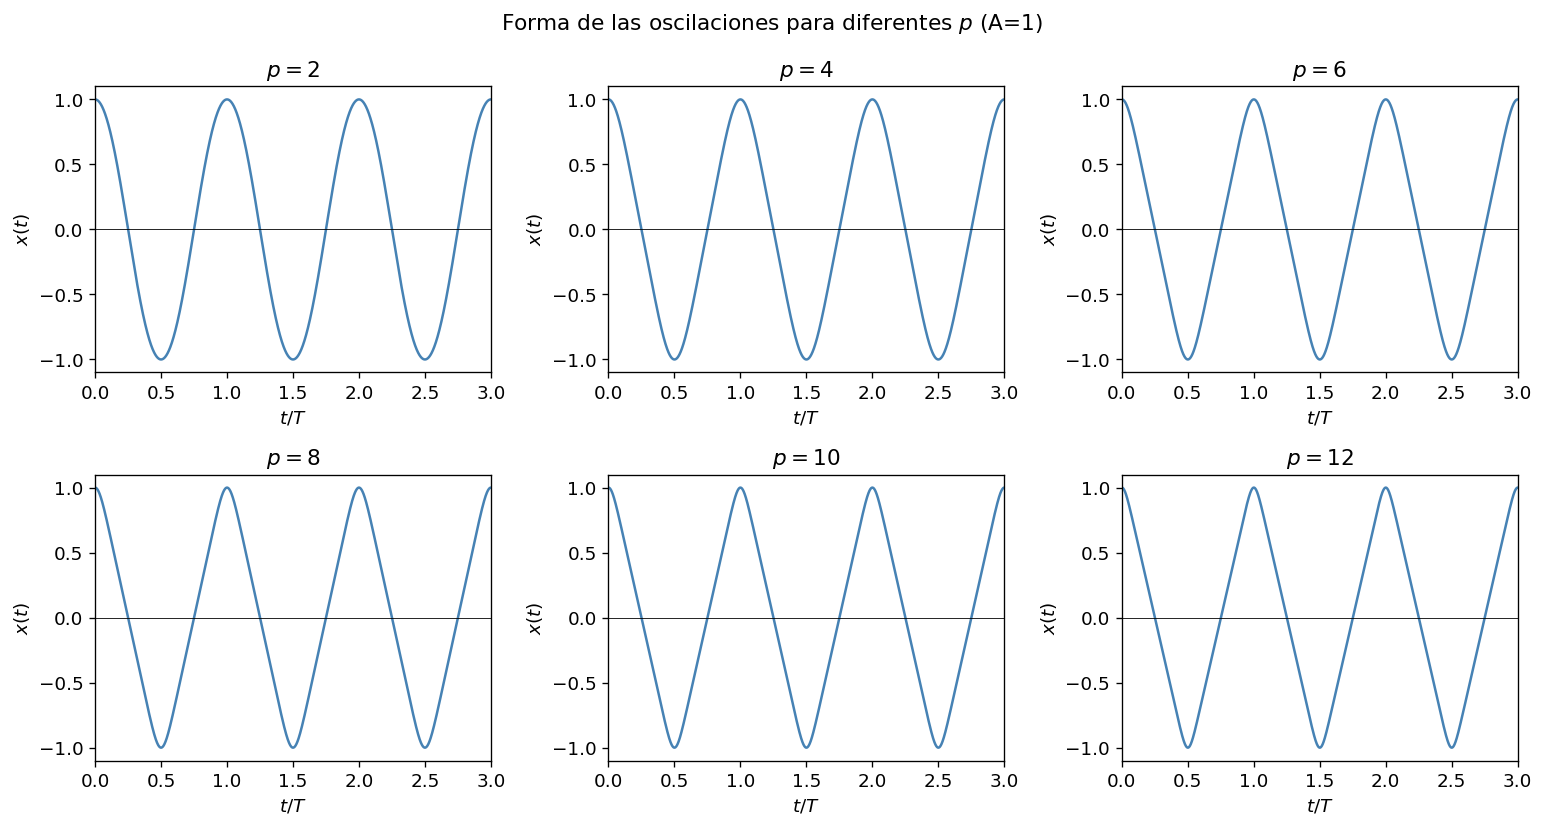

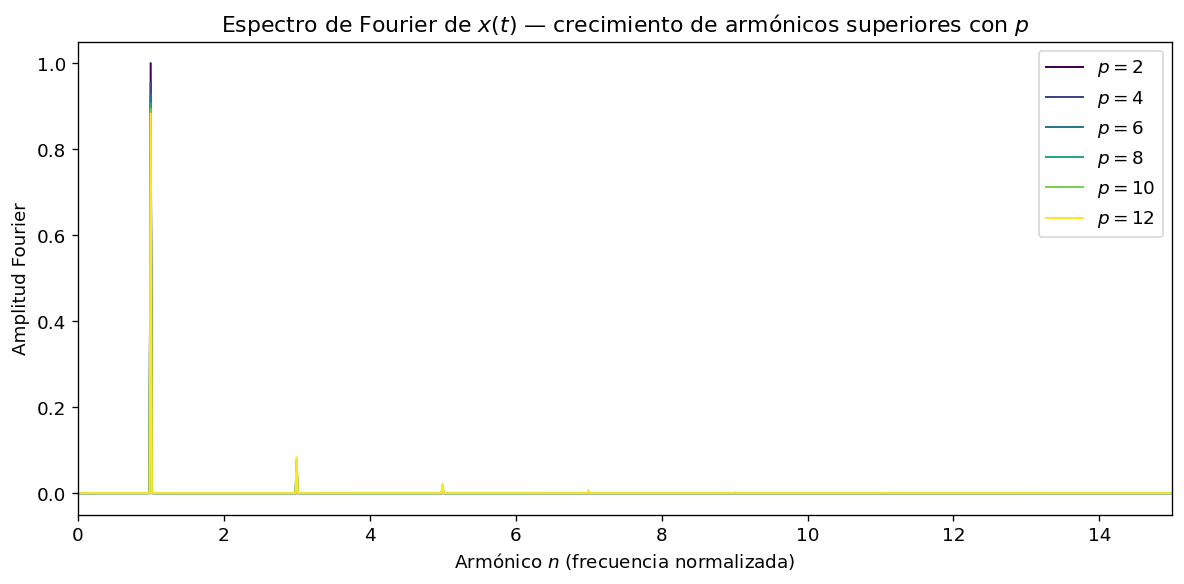

In [5]:
def plot_numeral3_all():
    p_vals = [2, 4, 6, 8, 10, 12]
    A = 1.0
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    axes = axes.flatten()

    for ax, p in zip(axes, p_vals):
        t, x, v = run_simulation(p, A, n_periods=3)
        # Normalize time to 1 period for comparison
        T = T_analytic(p, A)
        ax.plot(t / T, x, color='steelblue', lw=1.5)
        ax.set_title(f'$p = {p}$', fontsize=13)
        ax.set_xlabel('$t / T$')
        ax.set_ylabel('$x(t)$')
        ax.axhline(0, color='k', lw=0.5)
        ax.set_xlim([0, 3])

    plt.suptitle('Forma de las oscilaciones para diferentes $p$ (A=1)', fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_numeral3_fourier():
    """Show Fourier spectra to quantify harmonics."""
    p_vals = [2, 4, 6, 8, 10, 12]
    A = 1.0
    fig, ax = plt.subplots(figsize=(10, 5))

    colors = plt.cm.viridis(np.linspace(0, 1, len(p_vals)))
    for p, c in zip(p_vals, colors):
        T = T_analytic(p, A)
        h = choose_h(p, A)
        t, x, v = run_simulation(p, A, n_periods=64)
        N = len(x)
        freqs = np.fft.rfftfreq(N, d=(t[1]-t[0]))
        amp   = 2 * np.abs(np.fft.rfft(x)) / N
        f0    = 1.0 / T
        ax.plot(freqs / f0, amp, label=f'$p={p}$', color=c, lw=1.2)

    ax.set_xlim([0, 15])
    ax.set_xlabel('Armónico $n$ (frecuencia normalizada)')
    ax.set_ylabel('Amplitud Fourier')
    ax.set_title('Espectro de Fourier de $x(t)$ — crecimiento de armónicos superiores con $p$')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_numeral3_all()
plot_numeral3_fourier()

---
## Numeral 4 — Algoritmo para determinar el periodo por cruces por el origen

### Teoría del algoritmo

La función $x(t)$ cruza el origen **dos veces por periodo**: una vez con $v > 0$ (yendo hacia $+A$) y otra con $v < 0$ (regresando hacia $-A$). Por ello:

$$T = t_{n+2}^{(0)} - t_n^{(0)}$$

donde $t_n^{(0)}$ es el $n$-ésimo cruce por cero en la **misma dirección**.

**Algoritmo:**
1. Integrar las ecuaciones de movimiento por un tiempo suficientemente largo (al menos 3–4 periodos).
2. Detectar todos los instantes $t_i$ en que $x(t_i) = 0$ con $v(t_i) > 0$ (cruces ascendentes).
3. El periodo es el promedio de las diferencias consecutivas: $T = \langle t_{i+1} - t_i \rangle$.
4. Se usa **interpolación lineal** entre pasos para precisión sub-paso.

**¿Por qué al menos 3 cruces?** — Para movimiento potencialmente asimétrico se necesitan al menos 2 intervalos independientes para promediar y verificar consistencia. Exigir 3 cruces garantiza 2 medidas del periodo.

In [6]:
def detect_period_verbose(t, x, v, p, A):
    """Detect period with diagnostic output showing the crossings."""
    crossings_up   = []   # x: neg -> pos  (v > 0)
    crossings_down = []   # x: pos -> neg  (v < 0)

    for i in range(len(x) - 1):
        if x[i] <= 0.0 < x[i+1]:   # upward
            frac = -x[i] / (x[i+1] - x[i])
            crossings_up.append(t[i] + frac * (t[i+1] - t[i]))
        elif x[i] >= 0.0 > x[i+1]: # downward
            frac = x[i] / (x[i] - x[i+1])
            crossings_down.append(t[i] + frac * (t[i+1] - t[i]))

    T_up   = np.mean(np.diff(crossings_up))   if len(crossings_up)   > 1 else np.nan
    T_down = np.mean(np.diff(crossings_down)) if len(crossings_down) > 1 else np.nan
    T_mean = np.nanmean([T_up, T_down])
    T_ref  = T_analytic(p, A)

    print(f"  p={p}, A={A}")
    print(f"  Cruces ascendentes  : {[f'{c:.5f}' for c in crossings_up[:6]]}")
    print(f"  Cruces descendentes : {[f'{c:.5f}' for c in crossings_down[:6]]}")
    print(f"  T (desde subida)    = {T_up:.6f}")
    print(f"  T (desde bajada)    = {T_down:.6f}")
    print(f"  T promedio RK4      = {T_mean:.6f}")
    print(f"  T analítico         = {T_ref:.6f}")
    print(f"  Error relativo      = {abs(T_mean - T_ref)/T_ref:.2e}")
    print()
    return T_mean


for p_test in [2, 4, 6, 8, 10, 12]:
    t, x, v = run_simulation(p_test, A=1.0, n_periods=20)
    detect_period_verbose(t, x, v, p_test, A=1.0)

  p=2, A=1.0
  Cruces ascendentes  : ['4.71239', '10.99557', '17.27876', '23.56194', '29.84513', '36.12832']
  Cruces descendentes : ['1.57080', '7.85398', '14.13717', '20.42035', '26.70354', '32.98672']
  T (desde subida)    = 6.283185
  T (desde bajada)    = 6.283185
  T promedio RK4      = 6.283185
  T analítico         = 6.283185
  Error relativo      = 3.38e-12

  p=4, A=1.0
  Cruces ascendentes  : ['5.56222', '12.97852', '20.39482', '27.81112', '35.22742', '42.64372']
  Cruces descendentes : ['1.85407', '9.27037', '16.68667', '24.10297', '31.51927', '38.93557']
  T (desde subida)    = 7.416299
  T (desde bajada)    = 7.416299
  T promedio RK4      = 7.416299
  T analítico         = 7.416299
  Error relativo      = 2.54e-13

  p=6, A=1.0
  Cruces ascendentes  : ['6.30982', '14.72291', '23.13600', '31.54910', '39.96219', '48.37528']
  Cruces descendentes : ['2.10327', '10.51637', '18.92946', '27.34255', '35.75564', '44.16874']
  T (desde subida)    = 8.413093
  T (desde bajada)    

---
## Numeral 5 — Gráfica del periodo en función de la amplitud

### Teoría

De la ley de escala derivada anteriormente:

$$T(A) = C_p \cdot A^{1 - p/2}$$

donde $C_p = \dfrac{4}{p}B\!\left(\dfrac{1}{p},\dfrac{1}{2}\right)\sqrt{\dfrac{mp}{2k}}$ es una constante que depende solo de $p$, $m$ y $k$.

En escala log-log esta relación es una **recta de pendiente $1-p/2$**, verificable directamente.

In [7]:
def plot_numeral5(p):
    p = int(p)
    amplitudes = np.linspace(0.25, 3.0, 25)
    T_num, T_ana = compute_T_vs_A(p, amplitudes, n_periods=30)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Linear scale
    ax1.plot(amplitudes, T_num, 'o', ms=5, color='steelblue', label='RK4')
    ax1.plot(amplitudes, T_ana, '-', lw=2, color='coral',    label='Analítico')
    ax1.set_xlabel('Amplitud $A$')
    ax1.set_ylabel('Periodo $T$')
    ax1.set_title(f'$T$ vs $A$ — escala lineal  ($p={p}$)')
    ax1.legend()

    # Log-log scale — slope should be 1-p/2
    ax2.loglog(amplitudes, T_num, 'o', ms=5, color='steelblue', label='RK4')
    ax2.loglog(amplitudes, T_ana, '-', lw=2, color='coral',    label='Analítico')
    slope = 1 - p / 2
    # Fit line
    valid = ~np.isnan(T_num)
    if valid.sum() > 2:
        log_A  = np.log(amplitudes[valid])
        log_T  = np.log(T_num[valid])
        coeffs = np.polyfit(log_A, log_T, 1)
        ax2.loglog(amplitudes, np.exp(np.polyval(coeffs, np.log(amplitudes))),
                   '--', color='gray',
                   label=f'Ajuste: pendiente={coeffs[0]:.3f} (teórica={slope})')
    ax2.set_xlabel('Amplitud $A$')
    ax2.set_ylabel('Periodo $T$')
    ax2.set_title(f'$T$ vs $A$ — escala log-log  ($p={p}$)')
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


interact(plot_numeral5,
         p=IntSlider(min=2, max=12, step=2, value=4, description='p (par):',
                     style={'description_width': 'initial'}));

interactive(children=(IntSlider(value=4, description='p (par):', max=12, min=2, step=2, style=SliderStyle(desc…

---
## Numeral 6 — Movimiento oscilatorio pero no armónico para $p = 6$

### Teoría

Para $p=6$ el potencial es $V(x) = \frac{k}{6}x^6$ y la ecuación de movimiento es:

$$\ddot{x} = -x^5$$

El movimiento **es oscilatorio** porque el potencial es positivo, par y diverge en $\pm\infty$, garantizando la existencia de puntos de retorno.

**No es armónico** porque:
1. La fuerza **no es proporcional a $x$** — el principio de superposición no se cumple.
2. El espectro de Fourier contiene **armónicos impares** ($n = 1, 3, 5, \ldots$).
3. El periodo **depende de la amplitud** ($T \propto A^{-2}$ para $p=6$).
4. La forma de $x(t)$ se aleja marcadamente de una senoidal pura.

Comparamos cuantitativamente con $p=2$ (armónico) para subrayar las diferencias.

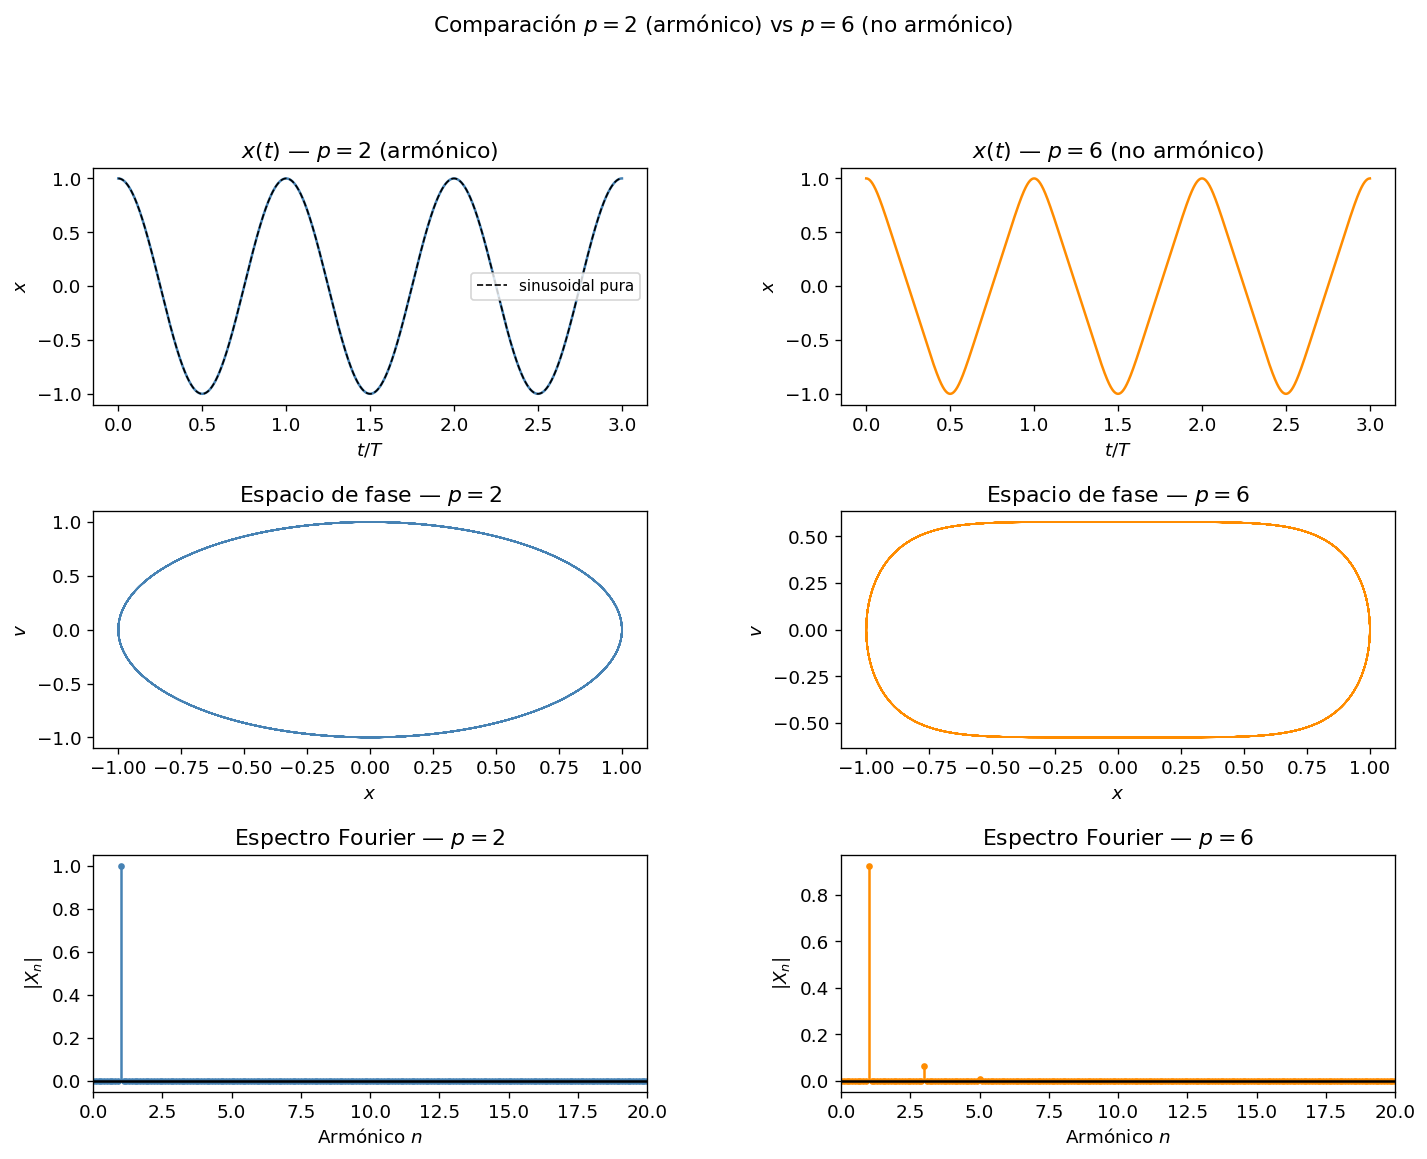

Espectro p=6 (primeros 7 armónicos):
  n=1: |X_n| = 0.926431
  n=2: |X_n| = 0.000001
  n=3: |X_n| = 0.063395
  n=4: |X_n| = 0.000000
  n=5: |X_n| = 0.008776
  n=6: |X_n| = 0.000000
  n=7: |X_n| = 0.001197

No isocronismo p=6:
  A=0.5: T_RK4=33.65237, T_analytic=33.65237, err=2.1e-11
  A=1.0: T_RK4=8.41309, T_analytic=8.41309, err=1.0e-11
  A=1.5: T_RK4=3.73915, T_analytic=3.73915, err=3.3e-12
  A=2.0: T_RK4=2.10327, T_analytic=2.10327, err=2.9e-12


In [8]:
def plot_numeral6():
    A = 1.0
    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    ax_x2  = fig.add_subplot(gs[0, 0])
    ax_x6  = fig.add_subplot(gs[0, 1])
    ax_ph2 = fig.add_subplot(gs[1, 0])
    ax_ph6 = fig.add_subplot(gs[1, 1])
    ax_sp2 = fig.add_subplot(gs[2, 0])
    ax_sp6 = fig.add_subplot(gs[2, 1])

    for p, ax_x, ax_ph, ax_sp, color in [
            (2, ax_x2, ax_ph2, ax_sp2, 'steelblue'),
            (6, ax_x6, ax_ph6, ax_sp6, 'darkorange')]:

        t, x, v = run_simulation(p, A, n_periods=10)
        T = T_analytic(p, A)

        # x(t) — normalized to one period for comparison
        mask = t <= 3 * T
        ax_x.plot(t[mask] / T, x[mask], color=color, lw=1.5)
        if p == 2:
            t_ref = t[mask]
            ax_x.plot(t_ref / T, A * np.cos(2 * np.pi * t_ref / T),
                      'k--', lw=1, label='sinusoidal pura')
            ax_x.legend(fontsize=9)
        ax_x.set_title(f'$x(t)$ — $p={p}$ ({"armónico" if p==2 else "no armónico"})')
        ax_x.set_xlabel('$t/T$');  ax_x.set_ylabel('$x$')

        # Phase portrait
        ax_ph.plot(x, v, color=color, lw=1)
        ax_ph.set_title(f'Espacio de fase — $p={p}$')
        ax_ph.set_xlabel('$x$');  ax_ph.set_ylabel('$v$')

        # Fourier spectrum
        N     = len(x)
        freqs = np.fft.rfftfreq(N, d=(t[1] - t[0]))
        amp   = 2 * np.abs(np.fft.rfft(x)) / N
        f0    = 1.0 / T
        ax_sp.stem(freqs / f0, amp, linefmt=color, markerfmt='.',
                   basefmt='k-')
        ax_sp.set_xlim([0, 20])
        ax_sp.set_title(f'Espectro Fourier — $p={p}$')
        ax_sp.set_xlabel('Armónico $n$');  ax_sp.set_ylabel('|$X_n$|')

    fig.suptitle('Comparación $p=2$ (armónico) vs $p=6$ (no armónico)', fontsize=13, y=1.01)
    plt.show()

    # Quantitative check: power in harmonics n>1 for p=6
    t6, x6, v6 = run_simulation(6, A, n_periods=64)
    T6 = T_analytic(6, A)
    N6 = len(x6)
    freqs6 = np.fft.rfftfreq(N6, d=(t6[1]-t6[0]))
    amp6   = 2 * np.abs(np.fft.rfft(x6)) / N6
    f0_6   = 1.0 / T6
    harmonics = np.round(freqs6 / f0_6).astype(int)

    print("Espectro p=6 (primeros 7 armónicos):")
    for n in range(1, 8):
        mask = harmonics == n
        if mask.any():
            print(f"  n={n}: |X_n| = {amp6[mask].max():.6f}")

    # Verify non-isochronism at p=6
    print("\nNo isocronismo p=6:")
    for Av in [0.5, 1.0, 1.5, 2.0]:
        t_, x_, v_ = run_simulation(6, Av, n_periods=30)
        y_ = np.column_stack([x_, v_])
        T_n = detect_period(t_, y_)
        T_a = T_analytic(6, Av)
        print(f"  A={Av}: T_RK4={T_n:.5f}, T_analytic={T_a:.5f}, err={abs(T_n-T_a)/T_a:.1e}")


plot_numeral6()

---
## Widget interactivo — Exploración global con $p \in [2, 12]$

Usa el deslizador para variar $p$ de **2 a 12** (valores pares) y la amplitud inicial $A$, y observar todos los efectos estudiados en los numerales anteriores de forma simultánea.

In [9]:
def explore_all(p, A):
    p = int(p)
    t, x, v = run_simulation(p, A, n_periods=6)
    T_ref = T_analytic(p, A)
    E  = 0.5 * v**2 + (1.0/p) * x**p
    E0 = E[0]

    fig = plt.figure(figsize=(14, 9))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    ax_xt  = fig.add_subplot(gs[0, :])
    ax_ph  = fig.add_subplot(gs[1, 0])
    ax_E   = fig.add_subplot(gs[1, 1])
    ax_sp  = fig.add_subplot(gs[1, 2])

    # x(t)
    ax_xt.plot(t / T_ref, x, color='steelblue', lw=1.5)
    ax_xt.set_xlabel('$t / T$');  ax_xt.set_ylabel('$x(t)$')
    ax_xt.set_title(f'Oscilador anarmónico  $p={p}$,  $A={A:.2f}$,  $T={T_ref:.4f}$')
    ax_xt.axhline(A,  ls='--', color='k', lw=0.8)
    ax_xt.axhline(-A, ls='--', color='k', lw=0.8)

    # Phase portrait
    ax_ph.plot(x, v, color='coral', lw=1)
    ax_ph.set_xlabel('$x$');  ax_ph.set_ylabel('$v$')
    ax_ph.set_title('Espacio de fase')

    # Energy conservation
    ax_E.semilogy(t / T_ref, np.abs((E - E0) / E0), color='seagreen', lw=1)
    ax_E.set_xlabel('$t/T$');  ax_E.set_ylabel('Error relativo $E$')
    ax_E.set_title(f'Conservación energía (máx {np.abs((E-E0)/E0).max():.1e})')

    # Spectrum
    N     = len(x)
    freqs = np.fft.rfftfreq(N, d=(t[1] - t[0]))
    amp   = 2 * np.abs(np.fft.rfft(x)) / N
    f0    = 1.0 / T_ref
    ax_sp.stem(freqs / f0, amp, linefmt='steelblue', markerfmt='.', basefmt='k-')
    ax_sp.set_xlim([0, 17]);  ax_sp.set_xlabel('Armónico $n$')
    ax_sp.set_ylabel('|$X_n$|')
    ax_sp.set_title('Espectro de Fourier')

    plt.show()

    # Print summary
    y_arr = np.column_stack([x, v])
    T_num = detect_period(t, y_arr)
    print(f"  T analítico = {T_ref:.6f}  |  T numérico = {T_num:.6f}  |  error = {abs(T_num-T_ref)/T_ref:.2e}")
    print(f"  v_max = {np.abs(v).max():.6f}  (teórico √(2E/m) = {np.sqrt(2*E0):.6f})")


interact(explore_all,
         p=IntSlider(min=2, max=12, step=2, value=2,
                     description='p:', style={'description_width': 'initial'}),
         A=FloatSlider(min=0.3, max=3.0, step=0.1, value=1.0,
                       description='A (amplitud):', style={'description_width': 'initial'}));

interactive(children=(IntSlider(value=2, description='p:', max=12, min=2, step=2, style=SliderStyle(descriptio…